<a href="https://colab.research.google.com/github/Noelsip/flood-bpn-smd/blob/main/Flood_AutoML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deteksi Anomali Banjir dengan Isolation Forest per Kota

Notebook ini memakai dataset yang sama (`processed/dataset_timeseries.csv`), tetapi implementasinya difokuskan ke **unsupervised anomaly detection**. Model utama adalah **Isolation Forest**, bukan supervised classifier.

Perubahan metodologi utama:
- model dilatih terpisah untuk **Balikpapan** dan **Samarinda**;
- setiap kota punya train/test split stratified sendiri;
- `StandardScaler` dan `IsolationForest` hanya di-fit pada train fold kota tersebut;
- test fold hanya di-transform dan diberi `anomaly_score` serta `is_anomaly`;
- `is_anomaly = 1` diinterpretasikan sebagai **indikasi banjir**;
- tidak ada FLAML, Random Forest, XGBoost, CatBoost, SMOTE, confusion matrix, atau classification report.


## 0. Clone Repository (Google Colab)
Saat berjalan di Colab, isi `REPO_URL` dengan repository yang berisi dataset dan folder `scripts/`.

In [1]:
import os
import sys
import subprocess

REPO_URL = "https://github.com/Noelsip/flood-bpn-smd.git"

def in_colab():
    return "google.colab" in sys.modules

if in_colab():
    repo_dir = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")
    if not os.path.isdir(repo_dir):
        subprocess.run(["git", "clone", REPO_URL], check=True)
    os.chdir(repo_dir)
    print("Direktori kerja:", os.getcwd())
else:
    print("Bukan Colab: memakai repository lokal.")


Direktori kerja: /content/flood-bpn-smd


## 1. Dependensi
Hanya dependensi inti yang dibutuhkan untuk deteksi anomali tabular.

In [2]:
if in_colab():
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy", "pandas", "scikit-learn", "matplotlib"
    ], check=True)
    print("Dependensi terpasang.")
else:
    print("Bukan Colab: pastikan requirements.txt sudah terpasang.")


Dependensi terpasang.


## 2. Import Library dan Konfigurasi

In [3]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.isolation_forest_per_city import (
    DEFAULT_CITIES,
    TARGET,
    attach_kecamatan_prior,
    evaluate_anomaly_overlap,
    feature_columns,
    run_per_city_isolation_forest,
    save_outputs,
)

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

SEED = 42
ANOMALY_CONTAMINATION = 0.05
TRAIN_RATIO = 0.80
SPLIT_MODE = "stratified_label_per_city"
MAX_KECAMATAN_PER_ALERT = 3

ROOT = Path.cwd()
DATA_PATH = ROOT / "processed" / "dataset_timeseries.csv"
OUT_DIR = ROOT / "outputs"
CLEAN_DIR = ROOT / "clean"
OUT_DIR.mkdir(exist_ok=True)

print("Dataset:", DATA_PATH)
print("Output :", OUT_DIR)


Dataset: /content/flood-bpn-smd/processed/dataset_timeseries.csv
Output : /content/flood-bpn-smd/outputs


## 3. Pemuatan Dataset
Dataset tetap sama. Data kota luar tidak dipakai untuk melatih model utama karena revisi memilih model yang belajar pola normal **per kota**. Split dilakukan secara stratified di dalam tiap kota: 80% data banjir dan 80% data tidak banjir masuk train, sisanya menjadi test.

In [4]:
data = pd.read_csv(DATA_PATH, parse_dates=["time"])
city_data = data[data["city"].isin(DEFAULT_CITIES)].copy()
features = feature_columns(city_data)

print("Seluruh dataset:", data.shape)
print("Dataset Kaltim:", city_data.shape)
print("Jumlah fitur numerik:", len(features))
print("Split mode:", SPLIT_MODE, "| train ratio:", TRAIN_RATIO)
print("Kota:", city_data["city"].unique().tolist())

if "split" in city_data.columns:
    display(city_data.groupby(["split", "city"])[TARGET].agg(hari="count", banjir_historis="sum"))
else:
    display(city_data.groupby("city")[TARGET].agg(hari="count", banjir_historis="sum"))


Seluruh dataset: (21570, 68)
Dataset Kaltim: (6418, 68)
Jumlah fitur numerik: 63
Split mode: stratified_label_per_city | train ratio: 0.8
Kota: ['Kota Samarinda', 'Kota Balikpapan']


hari  banjir_historis
split city                                  
test  Kota Balikpapan   643                3
      Kota Samarinda    641               27
train Kota Balikpapan  2566               36
      Kota Samarinda   2568               86

## 4. Eksplorasi Singkat
Bagian ini hanya deskriptif. Label historis banjir boleh ditampilkan sebagai konteks data, tetapi tidak dipakai untuk melatih Isolation Forest.

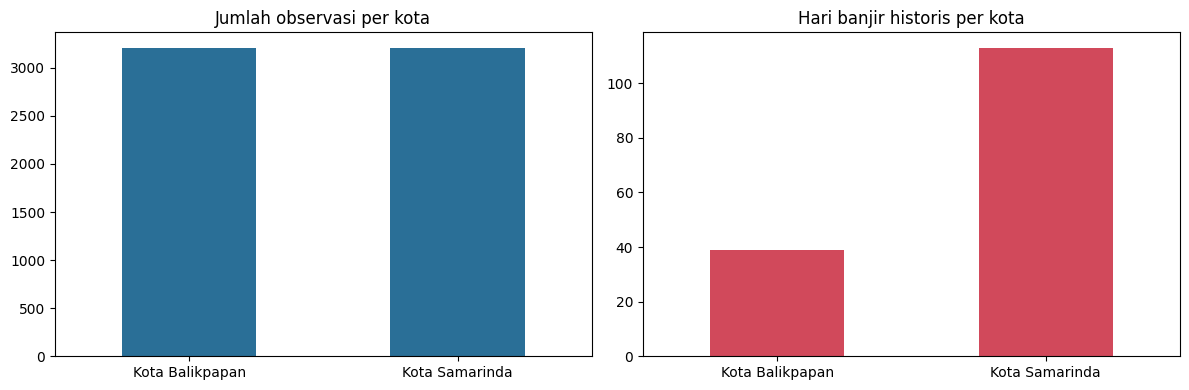

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
city_data.groupby("city").size().plot.bar(ax=ax[0], color="#2A6F97", rot=0)
ax[0].set_title("Jumlah observasi per kota")
ax[0].set_xlabel("")

if TARGET in city_data.columns:
    city_data.groupby("city")[TARGET].sum().plot.bar(ax=ax[1], color="#D1495B", rot=0)
    ax[1].set_title("Hari banjir historis per kota")
    ax[1].set_xlabel("")
else:
    ax[1].axis("off")

plt.tight_layout()
plt.show()


## 5. Isolation Forest per Kota
Setiap kota diproses sendiri. Di dalam tiap kota, data banjir dan tidak banjir historis dipisah lebih dulu untuk membentuk train 80% dan test 20% secara stratified. Label historis hanya dipakai untuk pembagian data, sedangkan scaler dan Isolation Forest hanya fit pada fitur train fold kota itu.

In [6]:
summary_df, anomaly_df, city_results = run_per_city_isolation_forest(
    city_data,
    cities=DEFAULT_CITIES,
    contamination=ANOMALY_CONTAMINATION,
    train_ratio=TRAIN_RATIO,
    split_mode=SPLIT_MODE,
    random_state=SEED,
)

kecamatan_df = attach_kecamatan_prior(
    anomaly_df,
    CLEAN_DIR,
    max_per_city=MAX_KECAMATAN_PER_ALERT,
    anomalies_only=True,
)
evaluation_df = evaluate_anomaly_overlap(anomaly_df)
save_outputs(summary_df, anomaly_df, OUT_DIR, kecamatan_df, evaluation_df)

summary_view = summary_df.copy()
for col in ["train_start", "train_end", "test_start", "test_end"]:
    summary_view[col] = pd.to_datetime(summary_view[col]).dt.date

display(summary_view)
print("Output disimpan:")
print("-", OUT_DIR / "isolation_forest_summary_per_city.csv")
print("-", OUT_DIR / "isolation_forest_anomaly_all.csv")
print("-", OUT_DIR / "isolation_forest_anomaly_balikpapan.csv")
print("-", OUT_DIR / "isolation_forest_anomaly_samarinda.csv")
print("-", OUT_DIR / "isolation_forest_anomaly_kecamatan.csv")
print("-", OUT_DIR / "isolation_forest_overlap_evaluation.csv")


,city,split_mode,train_days,test_days,train_start,train_end,test_start,test_end,detected_anomaly,anomaly_rate,mean_anomaly_score,max_anomaly_score,historical_flood_days,anomaly_on_historical_flood
0,Kota Balikpapan,stratified_label_per_city,2567,642,2016-07-29,2025-05-11,2016-07-30,2025-05-07,33,0.0514,0.4411,0.5768,8,0
1,Kota Samarinda,stratified_label_per_city,2566,643,2016-07-29,2025-05-11,2016-07-30,2025-05-01,32,0.0498,0.4479,0.6045,23,0


Output disimpan:
- /content/flood-bpn-smd/outputs/isolation_forest_summary_per_city.csv
- /content/flood-bpn-smd/outputs/isolation_forest_anomaly_all.csv
- /content/flood-bpn-smd/outputs/isolation_forest_anomaly_balikpapan.csv
- /content/flood-bpn-smd/outputs/isolation_forest_anomaly_samarinda.csv
- /content/flood-bpn-smd/outputs/isolation_forest_anomaly_kecamatan.csv
- /content/flood-bpn-smd/outputs/isolation_forest_overlap_evaluation.csv


## 6. Evaluasi Post-hoc per Kota
Evaluasi dipisah per kota dan tidak memakai confusion matrix. Label banjir historis hanya dipakai setelah model menghasilkan anomali, untuk melihat overlap dan posisi hari banjir dalam ranking skor anomali.

In [7]:
cols = [
    "city", "test_days", "detected_anomaly", "anomaly_rate",
    "mean_anomaly_score", "max_anomaly_score",
    "historical_flood_days", "anomaly_on_historical_flood",
]
display(summary_df[cols].round(4))

print("Overlap dan ranking anomaly score terhadap banjir historis:")
display(evaluation_df.round(4))
evaluation_df.to_csv(OUT_DIR / "isolation_forest_overlap_evaluation.csv", index=False)

for city, result in city_results.items():
    top = result.test.sort_values("anomaly_score", ascending=False).head(10)
    show_cols = [
        col for col in [
            "city", "time", "anomaly_score", "is_anomaly", "flood_anomaly", "anomaly_interpretation",
            TARGET, "rain", "precip", "soil", "rain_roll7_sum", "precip_roll7_sum", "soil_roll7_mean",
        ] if col in top.columns
    ]
    print(f"Top anomali test - {city}")
    display(top[show_cols])


,city,test_days,detected_anomaly,anomaly_rate,mean_anomaly_score,max_anomaly_score,historical_flood_days,anomaly_on_historical_flood
0,Kota Balikpapan,642,33,0.0514,0.4411,0.5768,8,0
1,Kota Samarinda,643,32,0.0498,0.4479,0.6045,23,0


Overlap dan ranking anomaly score terhadap banjir historis:


,city,test_days,historical_flood_days,anomaly_days,anomaly_rate,flood_days_flagged,overlap_rate,mean_score_flood_days,mean_score_non_flood_days,top_1pct_days,top_1pct_flood_hits,top_1pct_hit_rate,top_5pct_days,top_5pct_flood_hits,top_5pct_hit_rate,top_10pct_days,top_10pct_flood_hits,top_10pct_hit_rate
0,Kota Balikpapan,642,8,33,0.0514,0,0.0000,0.4201,0.4413,7,0,0.0000,33,0,0.0000,65,0,0.0000
1,Kota Samarinda,643,23,32,0.0498,0,0.0000,0.4475,0.4480,7,0,0.0000,33,0,0.0000,65,1,0.0435


Top anomali test - Kota Balikpapan


,city,time,anomaly_score,is_anomaly,flood_anomaly,anomaly_interpretation,Flood_next_3d,rain,precip,soil,rain_roll7_sum,precip_roll7_sum,soil_roll7_mean
378,Kota Balikpapan,2021-09-06,0.5768,1,1,indikasi banjir,0,18.8000,18.8000,0.4250,213.5000,213.5000,0.4263
609,Kota Balikpapan,2024-12-28,0.5759,1,1,indikasi banjir,0,3.6000,3.6000,0.2010,60.1000,60.1000,0.2021
601,Kota Balikpapan,2024-11-26,0.5741,1,1,indikasi banjir,0,29.3000,29.3000,0.2240,98.2000,98.2000,0.2113
608,Kota Balikpapan,2024-12-22,0.5699,1,1,indikasi banjir,0,15.1000,15.1000,0.1920,41.7000,41.7000,0.2064
607,Kota Balikpapan,2024-12-16,0.5690,1,1,indikasi banjir,0,2.2000,2.2000,0.2020,60.6000,60.6000,0.1959
602,Kota Balikpapan,2024-11-27,0.5684,1,1,indikasi banjir,0,9.0000,9.0000,0.2330,100.6000,100.6000,0.2146
611,Kota Balikpapan,2025-01-03,0.5637,1,1,indikasi banjir,0,3.5000,3.5000,0.2210,35.4000,35.4000,0.2079
603,Kota Balikpapan,2024-11-28,0.5616,1,1,indikasi banjir,0,10.9000,10.9000,0.2340,92.4000,92.4000,0.2181
604,Kota Balikpapan,2024-11-29,0.5585,1,1,indikasi banjir,0,11.7000,11.7000,0.2270,93.7000,93.7000,0.2214
605,Kota Balikpapan,2024-12-07,0.5571,1,1,indikasi banjir,0,0.9000,0.9000,0.2240,89.3000,89.3000,0.2360


Top anomali test - Kota Samarinda


,city,time,anomaly_score,is_anomaly,flood_anomaly,anomaly_interpretation,Flood_next_3d,rain,precip,soil,rain_roll7_sum,precip_roll7_sum,soil_roll7_mean
220,Kota Samarinda,2019-09-15,0.6045,1,1,indikasi banjir,0,0.0000,0.0000,0.2380,1.7000,1.7000,0.2436
221,Kota Samarinda,2019-09-19,0.6009,1,1,indikasi banjir,0,0.6000,0.6000,0.2350,1.3000,1.3000,0.2384
222,Kota Samarinda,2019-09-22,0.5912,1,1,indikasi banjir,0,1.8000,1.8000,0.2320,1.7000,1.7000,0.2360
609,Kota Samarinda,2024-12-25,0.5858,1,1,indikasi banjir,0,2.0000,2.0000,0.2320,76.1000,76.1000,0.2359
527,Kota Samarinda,2023-11-27,0.5771,1,1,indikasi banjir,0,21.7000,21.7000,0.3940,184.4000,184.4000,0.3703
225,Kota Samarinda,2019-09-30,0.5668,1,1,indikasi banjir,0,12.0000,12.0000,0.2470,30.8000,30.8000,0.2303
378,Kota Samarinda,2021-09-04,0.5665,1,1,indikasi banjir,0,11.0000,11.0000,0.4240,190.3000,190.3000,0.4246
224,Kota Samarinda,2019-09-29,0.5662,1,1,indikasi banjir,0,5.1000,5.1000,0.2330,27.5000,27.5000,0.2301
610,Kota Samarinda,2024-12-29,0.5651,1,1,indikasi banjir,0,6.2000,6.2000,0.2300,55.1000,55.1000,0.2300
223,Kota Samarinda,2019-09-26,0.5636,1,1,indikasi banjir,0,3.0000,3.0000,0.2300,9.2000,9.2000,0.2323


## 7. Visualisasi Skor Anomali
Grafik memperlihatkan distribusi skor pada test fold masing-masing kota dan garis ambang empiris yang memisahkan data normal/anomali menurut model.

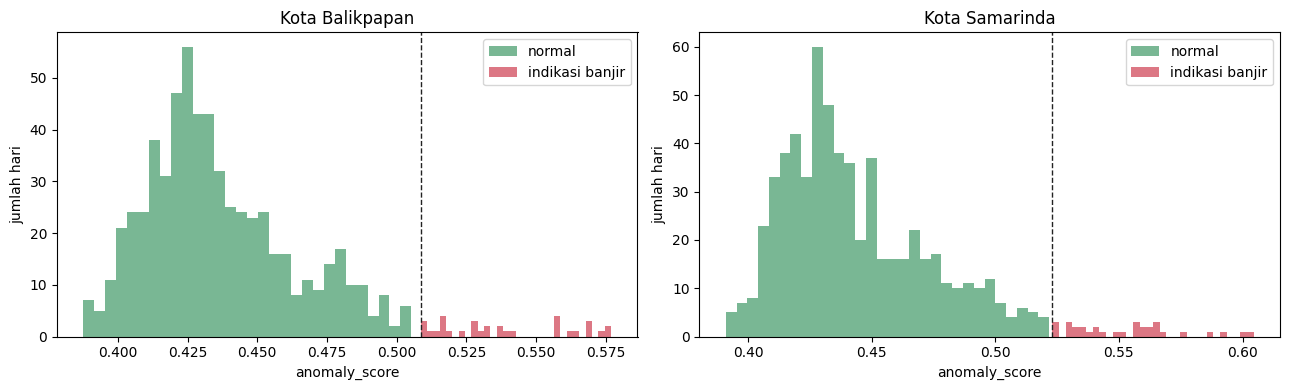

In [8]:
fig, axes = plt.subplots(1, len(city_results), figsize=(13, 4), squeeze=False)
for ax, (city, result) in zip(axes.ravel(), city_results.items()):
    test = result.test.copy()
    normal = test[test["is_anomaly"] == 0]
    anomaly = test[test["is_anomaly"] == 1]
    ax.hist(normal["anomaly_score"], bins=30, alpha=0.75, label="normal", color="#4C9F70")
    ax.hist(anomaly["anomaly_score"], bins=30, alpha=0.75, label="indikasi banjir", color="#D1495B")
    if not anomaly.empty:
        ax.axvline(anomaly["anomaly_score"].min(), color="#222222", linestyle="--", linewidth=1)
    ax.set_title(city)
    ax.set_xlabel("anomaly_score")
    ax.set_ylabel("jumlah hari")
    ax.legend()
plt.tight_layout()
plt.show()


## 8. Output Akhir
`is_anomaly = 1` adalah hasil deteksi anomali cuaca yang diinterpretasikan sebagai indikasi banjir. Kecamatan hanya dilampirkan pada output anomali sebagai prior lokasi historis dari `clean/banjir_*.csv`; kolom ini tidak digunakan untuk training model.

In [9]:
output_cols = [
    col for col in [
        "city", "time", "anomaly_score", "is_anomaly", "flood_anomaly", "anomaly_interpretation",
        TARGET, "rain", "precip", "soil", "rain_roll3_sum", "rain_roll7_sum", "rain_roll14_sum",
        "precip_roll3_sum", "precip_roll7_sum", "soil_roll3_mean", "soil_roll7_mean",
    ] if col in anomaly_df.columns
]
final_output = anomaly_df[output_cols].sort_values(["city", "time"]).reset_index(drop=True)
final_kecamatan_cols = [
    col for col in [
        "city", "time", "kecamatan", "banjir_historis", "anomaly_score", "is_anomaly",
        "flood_anomaly", "anomaly_interpretation", TARGET, "rain", "precip", "soil",
        "rain_roll7_sum", "precip_roll7_sum", "soil_roll7_mean",
    ] if col in kecamatan_df.columns
]
final_kecamatan = kecamatan_df[final_kecamatan_cols].sort_values(
    ["city", "time", "banjir_historis"], ascending=[True, True, False]
).reset_index(drop=True)

display(final_output.head(20))
print("Output anomali + prior kecamatan:")
display(final_kecamatan.head(30))

final_output.to_csv(OUT_DIR / "isolation_forest_final_output.csv", index=False)
final_kecamatan.to_csv(OUT_DIR / "isolation_forest_final_output_kecamatan.csv", index=False)
print("Disimpan:", OUT_DIR / "isolation_forest_final_output.csv")
print("Disimpan:", OUT_DIR / "isolation_forest_final_output_kecamatan.csv")


,city,time,anomaly_score,is_anomaly,flood_anomaly,anomaly_interpretation,Flood_next_3d,rain,precip,soil,rain_roll3_sum,rain_roll7_sum,rain_roll14_sum,precip_roll3_sum,precip_roll7_sum,soil_roll3_mean,soil_roll7_mean
0,Kota Balikpapan,2016-07-30,0.4768,0,0,normal,0,2.9000,2.9000,0.4190,21.2000,62.5000,146.1000,21.2000,62.5000,0.4253,0.4214
1,Kota Balikpapan,2016-08-02,0.4668,0,0,normal,0,5.0000,5.0000,0.4190,13.6000,50.4000,126.8000,13.6000,50.4000,0.4193,0.4227
2,Kota Balikpapan,2016-08-09,0.4426,0,0,normal,0,0.0000,0.0000,0.4050,6.8000,30.4000,80.8000,6.8000,30.4000,0.4150,0.4164
3,Kota Balikpapan,2016-08-14,0.4268,0,0,normal,0,4.2000,4.2000,0.3870,3.4000,3.7000,44.5000,3.4000,3.7000,0.3903,0.4003
4,Kota Balikpapan,2016-08-17,0.4242,0,0,normal,0,0.8000,0.8000,0.3790,10.0000,13.4000,38.8000,10.0000,13.4000,0.3843,0.3891
5,Kota Balikpapan,2016-08-19,0.4345,0,0,normal,0,0.0000,0.0000,0.3720,6.2000,15.5000,26.3000,6.2000,15.5000,0.3790,0.3836
6,Kota Balikpapan,2016-09-01,0.4391,0,0,normal,0,5.4000,5.4000,0.3610,11.5000,26.4000,32.0000,11.5000,26.4000,0.3590,0.3596
7,Kota Balikpapan,2016-09-02,0.4361,0,0,normal,0,10.1000,10.1000,0.3640,9.8000,24.1000,36.1000,9.8000,24.1000,0.3600,0.3599
8,Kota Balikpapan,2016-09-03,0.4332,0,0,normal,0,1.1000,1.1000,0.3680,17.5000,27.5000,46.2000,17.5000,27.5000,0.3613,0.3601
9,Kota Balikpapan,2016-09-05,0.4315,0,0,normal,0,10.2000,10.2000,0.3760,28.3000,45.2000,63.0000,28.3000,45.2000,0.3683,0.3633


Output anomali + prior kecamatan:


,city,time,kecamatan,banjir_historis,anomaly_score,is_anomaly,flood_anomaly,anomaly_interpretation,Flood_next_3d,rain,precip,soil,rain_roll7_sum,precip_roll7_sum,soil_roll7_mean
0,Kota Balikpapan,2017-08-20,Balikpapan Selatan,6,0.5169,1,1,indikasi banjir,0,0.8000,0.8000,0.4200,109.1000,109.1000,0.4239
1,Kota Balikpapan,2017-08-20,Balikpapan Tengah,4,0.5169,1,1,indikasi banjir,0,0.8000,0.8000,0.4200,109.1000,109.1000,0.4239
2,Kota Balikpapan,2017-08-20,Balikpapan Timur,4,0.5169,1,1,indikasi banjir,0,0.8000,0.8000,0.4200,109.1000,109.1000,0.4239
3,Kota Balikpapan,2019-06-07,Balikpapan Selatan,6,0.5401,1,1,indikasi banjir,0,24.8000,24.8000,0.4160,222.5000,222.5000,0.4224
4,Kota Balikpapan,2019-06-07,Balikpapan Tengah,4,0.5401,1,1,indikasi banjir,0,24.8000,24.8000,0.4160,222.5000,222.5000,0.4224
5,Kota Balikpapan,2019-06-07,Balikpapan Timur,4,0.5401,1,1,indikasi banjir,0,24.8000,24.8000,0.4160,222.5000,222.5000,0.4224
6,Kota Balikpapan,2019-09-13,Balikpapan Selatan,6,0.5120,1,1,indikasi banjir,0,0.9000,0.9000,0.3170,4.9000,4.9000,0.3239
7,Kota Balikpapan,2019-09-13,Balikpapan Tengah,4,0.5120,1,1,indikasi banjir,0,0.9000,0.9000,0.3170,4.9000,4.9000,0.3239
8,Kota Balikpapan,2019-09-13,Balikpapan Timur,4,0.5120,1,1,indikasi banjir,0,0.9000,0.9000,0.3170,4.9000,4.9000,0.3239
9,Kota Balikpapan,2019-09-16,Balikpapan Selatan,6,0.5240,1,1,indikasi banjir,0,0.0000,0.0000,0.3100,3.2000,3.2000,0.3183


Disimpan: /content/flood-bpn-smd/outputs/isolation_forest_final_output.csv
Disimpan: /content/flood-bpn-smd/outputs/isolation_forest_final_output_kecamatan.csv


---
## Catatan Metodologi
- Pendekatan ini adalah **unsupervised anomaly detection**, bukan supervised flood classification.
- Model dilatih **terpisah per kota** agar pola normal Balikpapan dan Samarinda tidak dicampur.
- Untuk setiap kota, data banjir dan tidak banjir dibagi 80/20 lebih dulu, lalu `StandardScaler.fit()` dan `IsolationForest.fit()` hanya memakai train fold kota tersebut.
- Test fold hanya dipakai untuk menghasilkan skor dan label anomali.
- Evaluasi dilakukan secara post-hoc melalui overlap dan ranking skor anomali terhadap catatan banjir historis, bukan confusion matrix.
- Kecamatan pada output adalah prior lokasi historis per kota, bukan hasil training atau fitur model.
- Tidak ada confusion matrix karena output utama bukan prediksi supervised terhadap kelas banjir, melainkan deteksi outlier/anomali cuaca sebagai indikasi banjir.
